In [1]:
from wilson.spectrum.spectrum2D import Spectrum2D
import numpy as np
# np.set_printoptions(precision=4)

import sys
sys.path.append("/home/vlew/CQCParse")

from CQCParse.parsing import GaussianDataParser, CFOURdataParser
from CQCParse.relay import DataVault
from wilson.utils import get_package_root

/home/vlew/miniconda3/envs/wilsonstuff/lib/python3.10/site-packages/numpy/_core/getlimits.py:548: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [2]:
wilson_root = get_package_root()
data_vault = DataVault(wilson_root+'/tests/test_database/mini_files_database.csv')
# data_vault = DataVault('/mnt/c/Users/vle014/OneDrive - UiT Office 365/Documents/files_fram/files_database.csv')

dataframe_gaussian = data_vault.getting_files_DB("gaussian")
method_basis = dataframe_gaussian[(dataframe_gaussian['code'] == 'ACAC') & (dataframe_gaussian['method'] != 'PBE0')][["code", "method", "basis_set"]]
tuples_method_basis = [(row['code'], row['method'], row['basis_set']) for index, row in method_basis.iterrows()]
dataframe_gaussian

,code,method,basis_set,g16_3quanta_full
0,FORM,HF,cc_pVQZ,/tests/test_database/dftGaussian/HFcc_pVQZ/g16...
2,FORM,B3LYP,cc_pVDZ,/tests/test_database/dftGaussian/B3LYPcc_pVDZ/...
3,ACAC,B3LYP,cc_pVQZ,/tests/test_database/dftGaussian/ACAC/B3LYPcc-...
4,ACDM,B3LYP,cc_pVQZ,/tests/test_database/dftGaussian/ACDM/B3LYPcc_...


In [3]:
# omega1 = np.arange(1280., 3150., 235.41)
# omega2 = np.arange(1589., 6050., 465.41)
omega1 = np.arange(1280., 3150., 35.41)
omega2 = np.arange(1589., 6050., 65.41)

datadict = data_vault.make_DatainputDict('gaussian', ('FORM', 'B3LYP', 'cc_pVDZ'), wilson_root)
dictInputs = {'parserObject': GaussianDataParser(datadict), 'el_terms_select': [0,1], 'mech_terms_select': [0,]}

# ------- setting up a Spectrum2D object
spectrumObj = Spectrum2D(omega1, omega2)
spectrumObj.load_data(dictInputs['parserObject'])
spectrumObj.setSpectrumSettings(Gamma_rc=10., diag_margin_rc=10., vib_levels_harmonic=False)
spectrumObj.addTerms(dictInputs['el_terms_select'], dictInputs['mech_terms_select']) # currently requires diag_margin_rc attribute to be set
spectrumObj.precalculateParts()

# print('spectrumObj.mech_avrg_tensors')
# for i in spectrumObj.mech_avrg_tensors:
#     print(repr(i), '\n')
    
print('before computedSpectrum.fundamentals')
print(spectrumObj.fundamentals)
print(sorted(list(spectrumObj.fundamentals.values())))
print('\ncomputedSpectrum.all_states\n', spectrumObj.all_states)

# ------- computing anharmonicities
sec_hypol_dataALL = 0

sec_hypol_data1 = 0
if dictInputs['mech_terms_select']:
    electrical, Qab_contrib_dict = spectrumObj.intensity_electrical()
    sec_hypol_data1 += electrical
    # print(f'\nElectrical {dictInputs["el_terms_select"]}')
    # print(repr(sec_hypol_data1))

sec_hypol_dataALL+=sec_hypol_data1

sec_hypol_data2 = 0
if dictInputs['mech_terms_select']:
    mechall, Qabc_contrib_dict = spectrumObj.intensity_mechanical()
    sec_hypol_data2 += mechall
    # print(f'Mechanical {dictInputs["mech_terms_select"]}')
    # print(repr(sec_hypol_data2))

sec_hypol_dataALL+=sec_hypol_data2

intensity = abs(sec_hypol_dataALL) ** 2

# print('\nSum both')
# print(repr(sec_hypol_dataALL))

# print('\nIntensity abs(sec_hypol_dataALL)**2')
# print(repr(intensity))


Used vibrational energy levels are harmonic? - False
before computedSpectrum.fundamentals
{'0': 2706.412, '1': 1808.055, '2': 1483.967, '3': 1167.45, '4': 2651.062, '5': 1233.413}
[1167.45, 1233.413, 1483.967, 1808.055, 2651.062, 2706.412]

computedSpectrum.all_states
 {('0',): 2706.412, ('1',): 1808.055, ('2',): 1483.967, ('3',): 1167.45, ('4',): 2651.062, ('5',): 1233.413, ('0', '0'): 5347.21, ('0', '0', '0'): 7922.393, ('1', '1'): 3597.5, ('1', '1', '1'): 5368.335, ('2', '2'): 2971.685, ('2', '2', '2'): 4463.155, ('3', '3'): 2328.254, ('3', '3', '3'): 3482.414, ('4', '4'): 5359.232, ('4', '4', '4'): 7924.685, ('5', '5'): 2463.662, ('5', '5', '5'): 3690.747, ('0', '1'): 4515.563, ('0', '1', '1'): 6306.104, ('0', '0', '1'): 7157.457, ('0', '2'): 4157.022, ('0', '2', '2'): 5611.384, ('0', '0', '2'): 6764.463, ('1', '2'): 3287.191, ('1', '2', '2'): 4770.08, ('1', '1', '2'): 5071.806, ('0', '1', '2'): 5961.343, ('0', '3'): 3866.408, ('0', '3', '3'): 5019.758, ('0', '0', '3'): 6499.752, 


self.intensities.max()==np.max(self.intensities.flatten(), axis=0): True 4.9514e+07


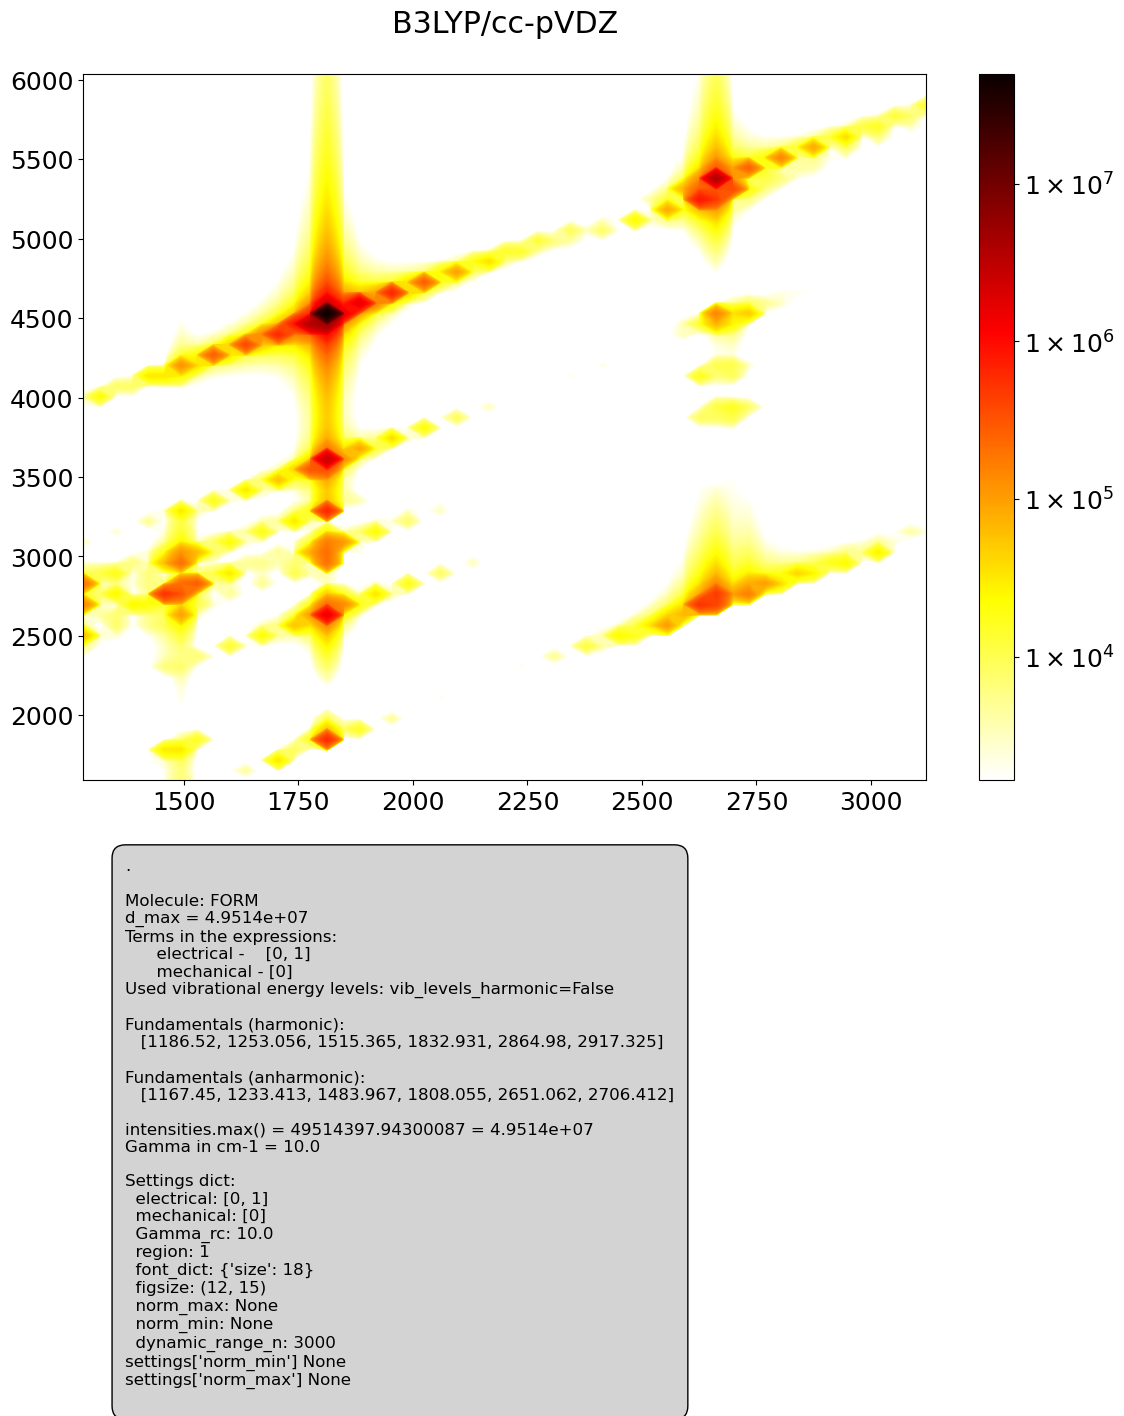

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
from wilson import rendering
import os

# this part is awkward right now; it can be updated according to changes in Spectrum2D class
settings_here = {'electrical': [0,1], 'mechanical': [0,],
                 'Gamma_rc': 10., 'region': 1,
                 'font_dict': {'size': 18}, 'figsize': (12, 15), 'norm_max': None, 'norm_min': None,
                 'dynamic_range_n': 3000}
other = {'regions': {1: ((1280., 3150., 235.41), (1589., 6050., 465.41))}, 'terms_selection': ([0,1], [0,]), 'w1mw2': False, 'log10': True}

name = rendering.make_name(datadict, vib_levels_harmonic=False, settings=settings_here, other=other, directory='.')
artist = rendering.SpectrumFigure(sec_hypol_dataALL, spectrumObj.w1_mesh, spectrumObj.w2_mesh, settings_here)
title_on_top, text_under_the_figure = rendering.make_texts4fig(datadict, spectrumObj, artist, settings_here, other, '.')
fig = artist.plot2Dmatplotlib(nametuple=(name, os.path.join(os.path.dirname('__file__')), title_on_top),
                                text_under_the_figure=text_under_the_figure, diagonal=False, to_save=False)
plt.show()